# Lesson 3 : Language Modelling
__Teaching Machines to predict next word__

*its doing one single things at its core:

__| Given the word so for predict next word.__

The entire field of large language models is an elaborate answer to this one question.


# What is Language model ?

A Language model assigns probablities to sequence of words.

P("cat sat on the mat") = 0.0023 <- reasonable english

P("mat sat on the cat") = 0.0008 <- grammatical but weird

P("sat the on mat the cat") = 0.000001 <- garbage

__more usefully, it answers. "Given everything so far what comes next ?"__

P(next word | "The cat sat on the ___ ")

P("mat") = 0.34

P("floor") = 0.21

P("roof") = 0.08

P("dog")= 0.01

.....

## Why is this enough to build ChatGPT ?

Because if you can predict the next word well enough, you implicitly must understand :

* Grammar (to predict grammatical continuations)

* Facts (to predict factually correct continuations)

* Reasoning ( to predict logically consistent continuations)

* style (to preddict contextually appropriate continuations)

__the "predict next word" objective forces the model to learn evrything about the language__

## Chapter 1 : N-Gram Language models

the simplest possible language model

Count how often word sequences appear in training data. use those counts as probability.

__Unigram model__ - each word independent:

P("cat") = Count("cat")/total words

__Bigram model__ - Probability depends on previous 1 word:

P("sat" | "cat") = Count( "cat sat")/Count("cat")

__trigram Model__ - Probability depends on previous 2 word:

P("sat" | "the cat") = Count("sat")/Count("the cat")



In [4]:
# N-Gram Language Model from Scratch
from collections import defaultdict, Counter
import random
import math
class NgramLanguageModel:
    def __init__(self,n):
        self.n=n
        self.count=defaultdict(Counter)
        self.vocab=set()

    def train(self,text):
        words=text.lower().split()
        self.vocab.update(words)
        for i in range (len(words)-self.n+1):
            context=tuple(words[i:i+self.n-1])
            target=words[i+self.n-1]
            self.count[context][target]+=1

    def probability(self,word,context):
        context=tuple(context[-self.n-1:])
        total=sum(self.count[context].values())
        if total==0:
            return 0.0
        return (self.count[context][word]+1)/(total+len(self.vocab))
    
    def predict_next(self,context,topn=5):
        context=tuple(context[-self.n+1:])
        scores={}
        for word in self.vocab:
            scores[word]=self.probability(word,context)
        return sorted(scores.items(),key=lambda x: -x[1])[:topn]
    def generate(self,seed,max_words=20):
        words=seed.lower().split()
        for _ in range(max_words):
            predictions = self.predict_next(words)
            # Sample from top predictions (not just argmax — adds variety)
            candidates, probs = zip(*predictions)
            total_probs=sum(probs)
            if total_probs==0:
                # Fallback: If everything is 0, give every word an equal chance
                probs = [1 / len(candidates)] * len(candidates)
            else:
                probs = [p / sum(probs) for p in probs]
            next_word = random.choices(candidates, weights=probs, k=1)[0]
            words.append(next_word)
        return " ".join(words)

    def perplexity(self, text):
        """
        Perplexity = how 'surprised' is the model by this text?
        Lower = better. A perplexity of K means the model is as confused
        as if it had to choose uniformly among K words at each step.
        """
        words   = text.lower().split()
        log_prob = 0
        count    = 0
        for i in range(self.n - 1, len(words)):
            context = words[i - (self.n-1) : i]
            word    = words[i]
            p       = self.probability(word, context)
            log_prob += math.log(p + 1e-10)
            count    += 1
        return math.exp(-log_prob / count)
    




text = """the king rules the kingdom with wisdom the queen advises the king
the prince will one day rule the kingdom the princess studies ancient wisdom
the knight protects the kingdom from enemies the wizard advises with magic
the king and queen rule together with justice for all people in the kingdom
the ancient kingdom has many rules that all people must follow
the wise king listens to his queen and his wizard before making decisions
"""
# Train Bigram and Trigram models
bigram=NgramLanguageModel(n=2)
trigram=NgramLanguageModel(n=3)
bigram.train(text)
trigram.train(text)

# --- Predictions ---
print("=== BIGRAM MODEL ===")
print("Context: ['the']")
for word, prob in bigram.predict_next(["the"]):
    print(f"  P('{word}' | 'the') = {prob:.4f}")

print("\n=== TRIGRAM MODEL ===")
print("Context: ['the', 'king']")
for word, prob in trigram.predict_next(["the", "king"]):
    print(f"  P('{word}' | 'the king') = {prob:.4f}")

# --- Text generation ---
print("\n=== TEXT GENERATION ===")
print("Bigram  seed='the king':")
print(" ", bigram.generate("the king", max_words=15))

print("\nTrigram seed='the king':")
print(" ", trigram.generate("the king", max_words=15))

# --- Perplexity comparison ---
test_sentence = "the king rules the kingdom"
weird_sentence = "wizard the kingdom rules ancient"
print(f"\n=== PERPLEXITY ===")
print(f"Normal sentence:  {trigram.perplexity(test_sentence):.2f}")
print(f"Weird sentence:   {trigram.perplexity(weird_sentence):.2f}")
print("(Lower perplexity = model finds text more natural)")


=== BIGRAM MODEL ===
Context: ['the']
  P('kingdom' | 'the') = 0.0909
  P('king' | 'the') = 0.0727
  P('princess' | 'the') = 0.0364
  P('wizard' | 'the') = 0.0364
  P('knight' | 'the') = 0.0364

=== TRIGRAM MODEL ===
Context: ['the', 'king']
  P('the' | 'the king') = 0.0455
  P('rules' | 'the king') = 0.0455
  P('and' | 'the king') = 0.0455
  P('many' | 'the king') = 0.0227
  P('king' | 'the king') = 0.0227

=== TEXT GENERATION ===
Bigram  seed='the king':
  the king and queen rule together king many rules that princess princess princess princess wizard princess studies

Trigram seed='the king':
  the king king princess king king many many many many princess many many kingdom wizard wizard kingdom

=== PERPLEXITY ===
Normal sentence:  21.33
Weird sentence:   16509636.22
(Lower perplexity = model finds text more natural)


# Fatal problems with N-Gram Language Model

Run the generation few times. you'll notice.

Problem 1 : No long range dependiencies :

" The king who defeated the dragon that terrorized the village ______ "

A trigram only sees the last 2 words. It has no idea "King" was mentioned 8 words ago when it needs to predict "ruled" vs "barked".

Problem 2 : Sparsity explodes with n :

with a 50000 word vocabulary :

* Bigram table : (50,000)2 = 2.5 billion possible pairs - most never seen 
* Trigram table : (50,000)3 = 125 trillion possible triples

you need exponential more data as n grows, but you also need larger n to capture longer context. this is curse of dimensionality.

Problem 3 : No generalization.

If training data has "The king rules" but not " The emperor rules" the model has zero knowledge about emperors, even though "king~emperor" in meaning. N-grams dont use embeddings - they treat every word as completly independent symbol .

__These three problems are exactly what neural language models solve.__

# Chapter 2 : Neural Languange Models

## The Bridge : Bengio's Neural LM(2003)

Youshua Bengios 2003 paper " A Neural Probabalistic Language model" Introduced the key ideas:

1. Represent words as dense vectors embeddings(solves problem 3)
2. Use a neural network to combine them - solves problem 1&2
3. Share parameters across all positions - solves sparsity






In [1]:
# Neural Language Model using PyTorch

import torch
import torch.nn as nn
import torch.nn.functional as F

corpus = """
the king rules the kingdom with wisdom the queen advises the king
the prince will one day rule the kingdom the princess studies ancient wisdom
the knight protects the kingdom from enemies the wizard advises with magic
the king and queen rule together with justice for all people in the kingdom
"""

words=corpus.lower().split()
vocab=set(words)
V=len(vocab)
w2i={word:i for i, word in enumerate(vocab)}
i2w={i:word for word,i in w2i.items()}

# Create training pairs for a Bigram model( input word id, target: word id)
pairs = [(w2i[words[i]],w2i[words[i+1]]) for i in range(len(words)-1)]

X=torch.tensor([p[0] for p in pairs],dtype=torch.long)
Y=torch.tensor([p[1] for p in pairs],dtype=torch.long)

print(f"Vocubalary size : {V}")
print(f"Number of training pairs : {len(pairs)}")
print(f" sample training pair :{ i2w[pairs[0][0]]} - > {i2w[pairs[0][1]]}")

# the Model
class neuralbigrammodel(nn.Module):
    def __init__(self,vocab_size,embed_dim,hidden_dim):
        super().__init__()
        # Layer 1 : word -> embedding
        self.embed=nn.Embedding(vocab_size,embed_dim)
        #Layer 2 : embedding -> hidden
        self.hidden=nn.Linear(embed_dim,hidden_dim)
        #Layer 3 : hidden -> output
        self.output=nn.Linear(hidden_dim,vocab_size)

    def forward(self,x):
        emb=self.embed(x)
        hidden=torch.tanh(self.hidden(emb))
        logits=self.output(hidden)
        return logits
    
model=neuralbigrammodel(V,embed_dim=16,hidden_dim=32)
optimizer=torch.optim.Adam(model.parameters(),lr=0.01)

# Training Loop
print("\n=== TRAINING NEURAL BIGRAM MODEL ===")
for epoch in range(500):
    logits=model(X)
    loss=F.cross_entropy(logits,Y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if (epoch+1)%100==0:
        print(f"Epoch {epoch+1:4d}  Loss: {loss.item():.4f}  "
              f"Perplexity: {torch.exp(loss).item():.2f}")
        
# generate text
def generate(model,seed_word,w2i,i2w,max_words=20,temperature=0.8):
    model.eval()
    word_out=[seed_word]
    current=torch.tensor([w2i[seed_word]])

    with torch.no_grad():
        for _ in range(max_words):
            logits=model(current)
            # temperature scaling : higher temp = more random, lower temp = more greedy
            probs=F.softmax(logits/temperature,dim=-1)
            next_id=torch.multinomial(probs,num_samples=1).item()
            word_out.append(i2w[next_id])
            current=torch.tensor([next_id])
    return " ".join(word_out)

print("\n=== GENERATED TEXT FROM NEURAL BIGRAM MODEL ===")
for seed in ["the","king","queen"]:
    print(f"Seed: '{seed}' -> {generate(model,seed,w2i,i2w)}")


# inspecting what model has learned
print("\n=== what comes after 'king'? ===")
model.eval()
with torch.no_grad():
    logits=model(torch.tensor([w2i["king"]]))
    probs=F.softmax(logits,dim=-1).squeeze()
    topk=torch.topk(probs,k=5)
    for prob,idx in zip(topk.values,topk.indices):
        print(f"  P('{i2w[idx.item()]}' | 'king') = {prob.item():.4f}")





    









Vocubalary size : 29
Number of training pairs : 50
 sample training pair :the - > king

=== TRAINING NEURAL BIGRAM MODEL ===
Epoch  100  Loss: 0.7065  Perplexity: 2.03
Epoch  200  Loss: 0.7029  Perplexity: 2.02
Epoch  300  Loss: 0.7018  Perplexity: 2.02
Epoch  400  Loss: 0.7013  Perplexity: 2.02
Epoch  500  Loss: 0.7011  Perplexity: 2.02

=== GENERATED TEXT FROM NEURAL BIGRAM MODEL ===
Seed: 'the' -> the kingdom the prince will one day rule the knight protects the princess studies ancient wisdom the king rules the kingdom
Seed: 'king' -> king the kingdom the kingdom from enemies the kingdom with magic the kingdom the kingdom with magic the kingdom from enemies
Seed: 'queen' -> queen rule together with magic the kingdom with wisdom the king rules the prince will one day rule the kingdom the

=== what comes after 'king'? ===
  P('rules' | 'king') = 0.3331
  P('and' | 'king') = 0.3331
  P('the' | 'king') = 0.3330
  P('in' | 'king') = 0.0001
  P('wisdom' | 'king') = 0.0001


# Cross Entropy Loss - The Universal LM Training Signal

This is the loss function that trains every single LLM ever built, including GPT-4 and Claude. Understand it deeply.


__When an LLM generates text, it's doing one thing repeatedly:__

__"Given everything so far, what's the probability of each possible next word?"__

__This code shows exactly how that works and how we measure if the model is doing it well.__

In [3]:
import torch
import torch.nn.functional as F

# Suppose our vocabulary is 5 words
# Model predicts raw score(logits) for each word
logits=torch.tensor([2.0, 1.0, 0.5, -1.0, 0.1]) #(raw score)

# Convert to probabilities using softmax
probs=F.softmax(logits,dim=0)
print("Probabilities:", [f"{p:.4f}" for p in probs.tolist()])
#

# Suppose correct next word is word #1 (index 1)
correct_word_id=1
correct_prob=probs[correct_word_id].item()
print("correct word probability:",f"{correct_prob:.4f}")
print(f"cross-entropy loss: {-torch.log(probs[correct_word_id]):.4f}")
# Loss = -log(P(correct word))
# Perfect model: P=1.0 → loss = -log(1.0) = 0.0
# Terrible model: P=0.01 → loss = -log(0.01) = 4.6

# Perplexity intituion
import math
print("\n=== PERPLEXITY INTUITION ===")
for p in [0.01, 0.1, 0.3, 0.5, 0.8, 1.0]:
    loss=-math.log(p)
    print(f"P(correct word)={p:.2f} -> loss={loss:.3f} ->  Perplexity={math.exp(loss):.2f}")



Probabilities: ['0.5585', '0.2055', '0.1246', '0.0278', '0.0835']
correct word probability: 0.2055
cross-entropy loss: 1.5824

=== PERPLEXITY INTUITION ===
P(correct word)=0.01 -> loss=4.605 ->  Perplexity=100.00
P(correct word)=0.10 -> loss=2.303 ->  Perplexity=10.00
P(correct word)=0.30 -> loss=1.204 ->  Perplexity=3.33
P(correct word)=0.50 -> loss=0.693 ->  Perplexity=2.00
P(correct word)=0.80 -> loss=0.223 ->  Perplexity=1.25
P(correct word)=1.00 -> loss=-0.000 ->  Perplexity=1.00


# SOFTMAX

What: Converts raw logits into probabilities that sum to 1.0

Why: Raw scores have no meaning alone — you can't compare them without normalizing

When: Final layer of every LLM before picking the next token


# NEGATIVE LOG (−log p)

What: log(probability) is always negative since p < 1, so we negate it to get a positive number

Why: Optimizers minimize loss — the negative sign makes that possible

Key values: p=1.0 → loss=0 | p=0.5 → loss=0.69 | p=0.01 → loss=4.6


# CROSS-ENTROPY LOSS

What: −log P(correct word) — penalizes the model for being wrong or uncertain

Why: Single number that backprop uses to update all model weights every training step

When: Every training step and fine-tuning — goal is to drive it toward 0


# PERPLEXITY

What: e^(average loss) = 1/P — "the model was choosing blindly among K words at each step"

Why: Loss is hard to interpret; perplexity gives it human-readable meaning — lower = smarter

Benchmarks: GPT-2 ~35 | GPT-3 ~20 | GPT-4 ~12 | 5-gram ~100+ | Random guess ~50,000


# The chain:

## Logits → Softmax → Probabilities → −log → Cross-entropy loss → Perplexity


# Chapter 3: The Autoregressive Generation Loop

__This is how every LLM generates text — including ChatGPT right now as it replies to you.__

In [5]:
def autoregressive_generate(model,prompt,w2i,i2w,max_new_tokens=20,temperature=1.0):
    model.eval()
    #tokenize the prompt
    tokens_ids=[w2i[word] for word in prompt.lower().split() if word in w2i]
    print(f"Prompt token ids:{tokens_ids}")
    print(f"Prompt tokens:{[i2w[i] for i in tokens_ids]}")
    print("\n Generating........")

    with torch.no_grad():
        for step in range(max_new_tokens):
            # Feed only the last token (bigram model)
            # In full transformer , we would feed the entire context
            current=torch.tensor([tokens_ids[-1]])
            logits=model(current)
            probs=F.softmax(logits/temperature,dim=1).squeeze()

            if temperature==0:
                # greedy sampling: pick the word with highest probability
                next_id=torch.argmax(probs).item()
            else:
                #sampling : pick next word based on probability distribution
                next_id=torch.multinomial(probs,num_samples=1).item()
            tokens_ids.append(next_id)
            print(f"  Step {step+1:2d}: '{i2w[next_id]}'  "
                  f"(P={probs[next_id].item():.3f})")
    return " ".join([i2w[i] for i in tokens_ids])


print("\n=== AUTOREGRESSIVE GENERATION ===")
result=autoregressive_generate(model,"the king",w2i,i2w,max_new_tokens=20,temperature=1)
print("Final generated text:",result)



=== AUTOREGRESSIVE GENERATION ===
Prompt token ids:[15, 7]
Prompt tokens:['the', 'king']

 Generating........
  Step  1: 'and'  (P=0.333)
  Step  2: 'queen'  (P=0.999)
  Step  3: 'advises'  (P=0.500)
  Step  4: 'with'  (P=0.500)
  Step  5: 'wisdom'  (P=0.333)
  Step  6: 'the'  (P=1.000)
  Step  7: 'king'  (P=0.250)
  Step  8: 'rules'  (P=0.333)
  Step  9: 'the'  (P=1.000)
  Step 10: 'king'  (P=0.250)
  Step 11: 'and'  (P=0.333)
  Step 12: 'queen'  (P=0.999)
  Step 13: 'rule'  (P=0.500)
  Step 14: 'the'  (P=0.500)
  Step 15: 'king'  (P=0.250)
  Step 16: 'the'  (P=0.333)
  Step 17: 'queen'  (P=0.083)
  Step 18: 'advises'  (P=0.500)
  Step 19: 'the'  (P=0.500)
  Step 20: 'wizard'  (P=0.083)
Final generated text: the king and queen advises with wisdom the king rules the king and queen rule the king the queen advises the wizard


# Temperature : The most important generation parameter

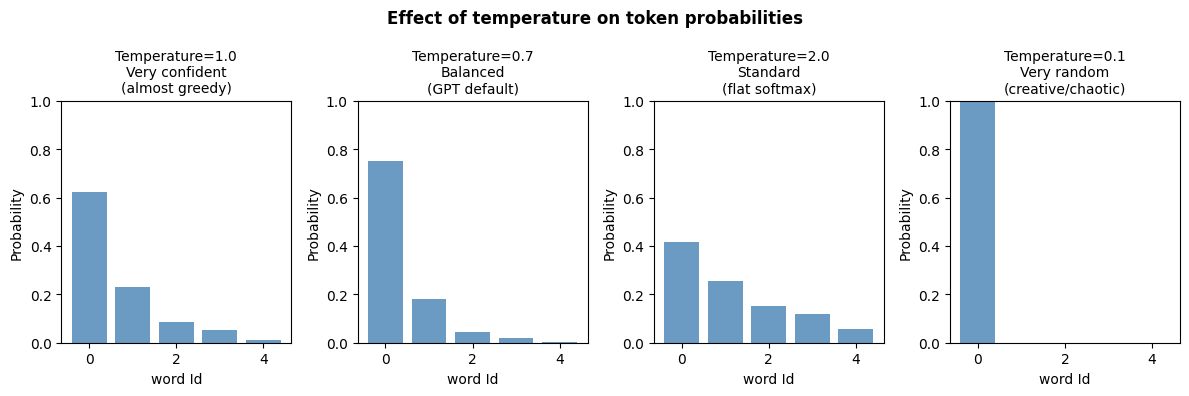

Saved figure as 'temperature_effect.png


In [7]:
import matplotlib.pyplot as plt
import numpy as np
logits=np.array([3.0,2.0,1.0,0.5,-1.0])
fig,axes=plt.subplots(1,4,figsize=(12,4))
temps=[1.0,0.7,2.0,0.1]
labels = ["Very confident\n(almost greedy)", 
          "Balanced\n(GPT default)", 
          "Standard\n(flat softmax)", 
          "Very random\n(creative/chaotic)"]

for ax,t,label in zip(axes,temps,labels):
    probs=np.exp(logits/t)
    probs=probs/probs.sum()
    ax.bar(range(len(logits)),probs,color='steelblue',alpha=0.8)
    ax.set_title(f"Temperature={t}\n{label}",fontsize=10)
    ax.set_xlabel("word Id")
    ax.set_ylabel("Probability")
    ax.set_ylim(0,1)

plt.suptitle("Effect of temperature on token probabilities",fontsize=12,fontweight='bold')
plt.tight_layout()
plt.savefig("temperature_effect.png",dpi=150)
plt.show()
print("Saved figure as 'temperature_effect.png")




# This why LLM has Temperature parameter:

* __Temperature=0__ -> Always picks Most likely word -> deterministic ,repetative
* __Temperature=1__ -> Samples from raw distribution -> natural
* __Temperature=2__ -> nearly random -> "creative"but often incoheret


# The Problem Neural LMs Still Have : Context Length

Our Neural bigram model only looks at 1 previous word. even if we extends to 5 or 10 words , we hit a wall :

" The king  who bravely  fought the dragon and saved the village people from certain doom and restored the peace to land ______"

To predict next word "Well" the model needs to remeber word "King" from 15+ words ago. A fixed- window neural LM cant do this - it would need to be retained with a new, larger window size.

__What we really need :__

* A model that can attend to any previous word, no matter how far back
* That Scales efficiently with sequence length
* That learns which previous words matter for predicting next one

__That is precisley Attention Mechanism give us.__

# Some Questions about Language Modeling :

## Q1: What is Perplexity and why s it used to evaluate LLMs?

Perplexity = how confused the model is. Calculated as exp(average loss).

Perplexity of 20 means: at each step, the model is as unsure as if it had to randomly pick from 20 equally likely words.

Lower = better, more confident model.

Used because it doesn't need labeled data — you just feed it text and measure how well it predicts the next word. That's why it's called "intrinsic."

## Q2: Whats difference between Autoregressive and masked languge modelling?

Autoregressive (GPT) — reads left to right only, predicts the next word using only past words. Built for generating text.

Masked (BERT) — hides random words anywhere in the sentence, predicts them using words from both sides (before and after). Built for understanding text (classification, search, etc.), not generation.

One-liner: GPT writes forward, BERT fills in blanks looking both ways.

## Q3: Why is cross-entropy the right loss for language modelling ?

At every step, the model is choosing one correct word out of the whole vocabulary — that's just classification, where the "classes" are vocab words.

Cross-entropy = penalty for how low a probability the model gave to the correct word.
Minimizing this penalty = maximizing the probability of correct words = exactly what we want a language model to do.

So it's not an arbitrary choice — it's the mathematically correct loss for "pick the right word out of many options."

## Q4: What is Teacher Forcing ?

During training: even if the model guesses wrong at step 3, we still feed it the correct word for step 4 — not its own wrong guess. This keeps training stable and stops one mistake from snowballing into garbage.

During inference (actual generation): there's no "correct" word to feed it anymore — the model has to feed its own predictions back into itself.

This mismatch (correct words during training vs. own guesses during real use) is called exposure bias — the model never practiced recovering from its own mistakes, so errors can compound during real generation.

## Q: what does a language model fundamentally do?

It predicts the probability of the next word given everything that came before it.

## Q: What are the 3 fatal problems with n-gram models?

* Sparsity — most word combinations never appear in training data, so the model assigns them zero probability even if they're perfectly valid sentences.
* No long-range memory — a bigram/trigram only looks at the last 1-2 words, so it can't connect "The trophy didn't fit in the suitcase because it was too big" — it has no idea what "it" refers to.
* Memory explosion — storing counts for every possible word combination grows exponentially with vocabulary size and n, making large n-grams computationally impossible.

## Q:What is temperature, and what happens at temperature=0?

Temperature controls how "confident vs random" the model's word choices are, by scaling logits before softmax.

At temperature=0, it becomes greedy decoding — the model always picks the single highest-probability word, every single time. No randomness, fully deterministic, same output every run.

## Q: Why can't even a neural LM with a 10-word window handle long documents?

Because it's still a fixed window — it physically cannot see anything beyond those last 10 words. Once a name, fact, or topic scrolls past that window, it's gone — the model has no memory of it. This is exactly the problem Transformers solve with attention, which lets the model look back across the entire input, not just a fixed-size recent window.